In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
auto = fetch_openml(
    name='autoMpg',
    version=1,
    as_frame=True,
    parser='auto'
)

df = auto.frame

print(df.head())
print(df.columns)

  cylinders  displacement  horsepower  weight  acceleration model origin  \
0         8         307.0       130.0    3504          12.0    70      1   
1         8         350.0       165.0    3693          11.5    70      1   
2         8         318.0       150.0    3436          11.0    70      1   
3         8         304.0       150.0    3433          12.0    70      1   
4         8         302.0       140.0    3449          10.5    70      1   

   class  
0   18.0  
1   15.0  
2   18.0  
3   16.0  
4   17.0  
Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model', 'origin', 'class'],
      dtype='object')


In [4]:
# Find target column
if 'mpg' in df.columns:
    target = 'mpg'
elif 'class' in df.columns:
    target = 'class'
else:
    raise Exception("MPG column not found!")

# Select required columns
df = df[['displacement', target]].copy()

# Rename columns
df.columns = ['displacement', 'mpg']

# Convert to numeric
df['displacement'] = pd.to_numeric(
    df['displacement'],
    errors='coerce'
)

df['mpg'] = pd.to_numeric(
    df['mpg'],
    errors='coerce'
)

# Remove missing values
df.dropna(inplace=True)

print(df.head())
print("Dataset Shape:", df.shape)

   displacement   mpg
0         307.0  18.0
1         350.0  15.0
2         318.0  18.0
3         304.0  16.0
4         302.0  17.0
Dataset Shape: (398, 2)


In [5]:
X = df[['displacement']]
y = df['mpg']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (398, 1)
Target Shape: (398,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (318, 1)
Testing Data: (80, 1)


In [7]:
poly1 = PolynomialFeatures(degree=1)

X_train_poly1 = poly1.fit_transform(X_train)
X_test_poly1 = poly1.transform(X_test)

model1 = LinearRegression()

model1.fit(
    X_train_poly1,
    y_train
)

y_pred1 = model1.predict(X_test_poly1)

In [8]:
poly2 = PolynomialFeatures(degree=2)

X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model2 = LinearRegression()

model2.fit(
    X_train_poly2,
    y_train
)

y_pred2 = model2.predict(X_test_poly2)

In [9]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model3 = LinearRegression()

model3.fit(
    X_train_poly3,
    y_train
)

y_pred3 = model3.predict(X_test_poly3)

In [10]:
# Degree 1
mse1 = mean_squared_error(y_test, y_pred1)
r21 = r2_score(y_test, y_pred1)

# Degree 2
mse2 = mean_squared_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

# Degree 3
mse3 = mean_squared_error(y_test, y_pred3)
r23 = r2_score(y_test, y_pred3)

print("----- MODEL EVALUATION -----")

print("\nLinear Regression (Degree 1)")
print(f"MSE      : {mse1:.4f}")
print(f"R² Score : {r21:.4f}")

print("\nPolynomial Regression (Degree 2)")
print(f"MSE      : {mse2:.4f}")
print(f"R² Score : {r22:.4f}")

print("\nPolynomial Regression (Degree 3)")
print(f"MSE      : {mse3:.4f}")
print(f"R² Score : {r23:.4f}")

----- MODEL EVALUATION -----

Linear Regression (Degree 1)
MSE      : 18.1025
R² Score : 0.6633

Polynomial Regression (Degree 2)
MSE      : 15.1074
R² Score : 0.7190

Polynomial Regression (Degree 3)
MSE      : 14.9436
R² Score : 0.7221


In [11]:
X_range = pd.DataFrame({
    'displacement': np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

In [12]:
y_plot1 = model1.predict(
    poly1.transform(X_range)
)

y_plot2 = model2.predict(
    poly2.transform(X_range)
)

y_plot3 = model3.predict(
    poly3.transform(X_range)
)

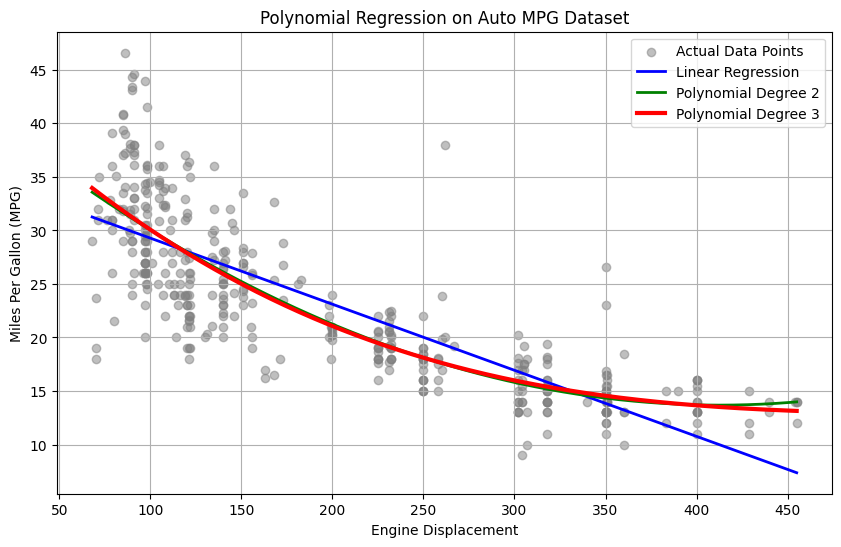

In [13]:
plt.figure(figsize=(10, 6))

# Actual data points
plt.scatter(
    X,
    y,
    color='gray',
    alpha=0.5,
    label='Actual Data Points'
)

# Linear Regression
plt.plot(
    X_range['displacement'],
    y_plot1,
    color='blue',
    linewidth=2,
    label='Linear Regression'
)

# Polynomial Degree 2
plt.plot(
    X_range['displacement'],
    y_plot2,
    color='green',
    linewidth=2,
    label='Polynomial Degree 2'
)

# Polynomial Degree 3
plt.plot(
    X_range['displacement'],
    y_plot3,
    color='red',
    linewidth=3,
    label='Polynomial Degree 3'
)

plt.title(
    "Polynomial Regression on Auto MPG Dataset"
)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")

plt.legend()
plt.grid(True)

plt.show()